In [1]:
import torch
import numpy as np

from classifier_model import BG

from matplotlib import pyplot as plt
from IPython import display
from scipy.ndimage import gaussian_filter1d

%matplotlib inline

In [3]:
dt = 0.002
num_steps = 1000
rl_scaler = 1
units = 128

min_omega = 25
max_omega = 70

input_dim = 1
action_dim = 2

print(f"duration of a trial {dt* num_steps * rl_scaler} seconds")

duration of a trial 2.0 seconds


In [28]:
model = BG(input_dim, action_dim, units, dt,
           min_omega, max_omega, pd_flag=1)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

eps = np.finfo(np.float32).eps.item()

In [ ]:
num_epochs = 4000
class_seed = np.random.randint(0, 2, num_epochs)
plt.hist(class_seed)
plt.title('Class distribution')
plt.show()

running_twenty_avg = []

for episode in range(num_epochs):

    if class_seed[episode] == 0:
        desired = 0 # short        
        offset = int(0.4/(dt * rl_scaler))
        y_label = torch.tensor([1.0, 0.0]).reshape(1, -1)
    else:
        desired = 1 # long
        offset = int(1.6/(dt * rl_scaler))
        y_label = torch.tensor([0.0, 1.0]).reshape(1, -1)

    t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
    t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
    state_stimuli = 5*np.sin(2*np.pi*5*t_stimuli)
    state_noise = np.sin(2*np.pi*5*t_noise) 
    state = np.hstack((state_stimuli, state_noise))

    r1 = torch.ones(1, units)
    phi1 = torch.rand(1, units)
    r2 = torch.ones(1, units)
    phi2 = torch.rand(1, units)
    state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
    (pred, value, zipper) = model(state, r1, phi1, r2, phi2)
    pred_class = torch.argmax(pred, 1).item()
    p = torch.max(pred, 1)[0]
    reward = 0.0 if pred_class != desired else 1.0

    cL = torch.nn.HuberLoss()(torch.tensor(reward), value)
    aL = -torch.log(p) * (reward - value)
    loss = cL + aL
        
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if len(running_twenty_avg)<20:
        running_twenty_avg.append(reward)
    else:
        running_twenty_avg.append(reward)
        running_twenty_avg.pop(0)

    if (episode+1) % 20 == 0:
        print(f'E {episode}, L: {loss.item()}, d: {desired}, p: {pred_class}, Avg: {np.mean(running_twenty_avg)}')
    
    if (episode+1) % 200 == 0:
        torch.save(model.state_dict(), f'temp_bisec.pth')
        np.save(f'd1_temp_bisec_control.npy', model.d1.omegas.clone().detach().numpy())
        np.save(f'd2_temp_bisec_control.npy', model.d2.omegas.clone().detach().numpy())


E 19, L: -0.171995609998703, d: 0, p: 0, Avg: 0.4
E 39, L: -0.2296186089515686, d: 1, p: 1, Avg: 0.7
E 59, L: -0.1735755354166031, d: 0, p: 0, Avg: 0.5
E 79, L: -0.1924307942390442, d: 1, p: 1, Avg: 0.9
E 99, L: -0.20785462856292725, d: 0, p: 0, Avg: 0.5
E 119, L: -0.16753262281417847, d: 0, p: 0, Avg: 0.3
E 139, L: -0.15401916205883026, d: 1, p: 1, Avg: 0.7
E 159, L: -0.18311931192874908, d: 1, p: 1, Avg: 0.8
E 179, L: -0.09723234176635742, d: 1, p: 1, Avg: 0.8
E 199, L: 0.30292654037475586, d: 0, p: 1, Avg: 0.6
E 219, L: 0.3682258129119873, d: 0, p: 1, Avg: 0.3
E 239, L: -0.20596764981746674, d: 1, p: 1, Avg: 0.6
E 259, L: -0.14434896409511566, d: 1, p: 1, Avg: 0.7
E 279, L: -0.10866626352071762, d: 0, p: 0, Avg: 0.6
E 299, L: -0.15768873691558838, d: 0, p: 0, Avg: 0.8
E 319, L: -0.21955028176307678, d: 0, p: 0, Avg: 1.0
E 339, L: -0.18404856324195862, d: 0, p: 0, Avg: 0.8
E 359, L: -0.1809447854757309, d: 0, p: 0, Avg: 0.7
E 379, L: 0.4704709053039551, d: 1, p: 0, Avg: 0.5
E 399, L:

In [30]:
jumbo_mon = []

for iter in range(10):

    iter_mon = []    

    for d in np.arange(0.4, 1.8, 0.2):        
        offset = int(d/(dt * rl_scaler))
        t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
        t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
        state_stimuli = 5*np.sin(2*np.pi*5*t_stimuli)
        state_noise = np.sin(2*np.pi*5*t_noise) 
        state = np.hstack((state_stimuli, state_noise))
        state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
 
        r1 = torch.ones(1, units)
        phi1 = torch.rand(1, units)
        r2 = torch.ones(1, units)
        phi2 = torch.rand(1, units)
        ff_state = torch.zeros(1, units)
        
        model = BG(input_dim, action_dim, units, dt,
                   min_omega, max_omega, pd_flag=0)
        model.load_state_dict(torch.load(f'temp_bisec.pth'))
        model.d1.omegas.data = torch.tensor(np.load(f'd1_temp_bisec_control.npy'))
        model.d2.omegas.data = torch.tensor(np.load(f'd2_temp_bisec_control.npy'))
        (pred, value, zipper) = model(state, r1, phi1, r2, phi2)
        print(pred)
        pred_class = torch.argmax(pred, 1).item()
        iter_mon.append(pred_class)

    jumbo_mon.append(iter_mon)
jumbo_mon = np.array(jumbo_mon)

C:\Users\sinha\AppData\Local\Temp\ipykernel_18492\1688404222.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'temp_bisec.pth'))


tensor([[0.5415, 0.4585]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5259, 0.4741]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5231, 0.4769]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5120, 0.4880]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5036, 0.4964]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5160, 0.4840]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5092, 0.4908]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5477, 0.4523]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5231, 0.4769]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5249, 0.4751]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5068, 0.4932]], grad_fn=<SoftmaxBackward0>)
tensor([[0.4922, 0.5078]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5036, 0.4964]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5045, 0.4955]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5261, 0.4739]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5477, 0.4523]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5058, 0.4942]], grad_fn=<SoftmaxBackward0>)
tensor([[0.5235, 0.4765]], grad_fn=<SoftmaxBackward0>)
tensor([[0

In [23]:
jumbo_mon

array([[0, 0, 0, 1, 1, 1, 1],
       [1, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 1, 1, 0, 1],
       [0, 0, 0, 1, 0, 1, 1]])

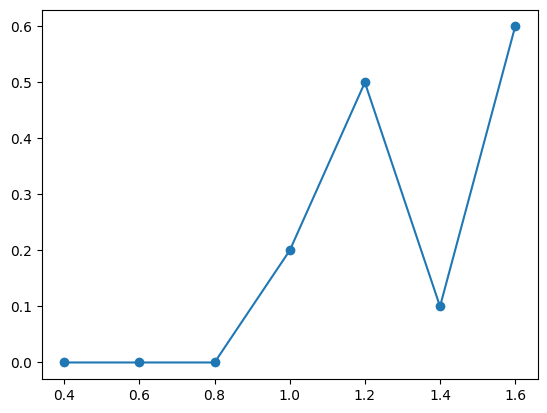

In [31]:
plt.plot(np.arange(0.4, 1.8, 0.2), np.mean(jumbo_mon, 0), '-o')
plt.show()